# 광파오븐 × 1인 가구 — 네이버 지식인 크롤링
- **목적**: 1인 가구의 광파오븐 Pain Point 수집 (가설별 키워드 분류)
- **수집 항목**: 제목 / 질문 본문 / 채택 답변 / 키워드 카테고리
- **실행 환경**: Google Colab 권장


In [1]:
# Google Colab 실행 시 아래 두 줄 주석 해제
# !apt-get install -y default-jdk > /dev/null 2>&1
# !pip install selenium beautifulsoup4 pandas tqdm -q

!pip install selenium beautifulsoup4 pandas tqdm -q


In [8]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup as bs
from tqdm import tqdm
import time, re, random
import pandas as pd
from datetime import datetime

# =====================================================================
# 수집 기간 설정 — 오늘 기준 3년 치
# =====================================================================
_today           = datetime.today()
_three_years_ago = _today.replace(year=_today.year - 3)
START_DATE = _three_years_ago.strftime("%Y%m%d")  # 예: "20230615"
END_DATE   = _today.strftime("%Y%m%d")             # 예: "20260615"

print(f"수집 기간: {START_DATE} ~ {END_DATE}")

# =====================================================================
# 키워드 정의 — 가설(카테고리)별로 분류
# =====================================================================
# 수집 후 어떤 Pain Point가 어떤 맥락에서 나왔는지 추적 가능하도록
# 카테고리 컬럼을 함께 저장함

KEYWORDS = {

    # ── 가설 A: 공간 제약
    # 원룸/오피스텔 등 좁은 주방 때문에 광파오븐 고민하는 맥락
    "A_공간제약": [
        "원룸 광파오븐",
        "자취방 광파오븐",
        "오피스텔 광파오븐",
        "원룸 오븐 추천",
    ],

    # ── 가설 B: 구매 결정 장벽 (전자레인지·에어프라이어 vs 광파오븐)
    # 1인 가구가 어떤 가전을 선택할지 비교·고민하는 맥락
    "B_구매비교": [
        "자취 광파오븐",
        "1인가구 광파오븐",
        "혼자 사는데 광파오븐",
        "자취 전자레인지 광파오븐",
        "자취 에어프라이어 광파오븐",
        "자취 오븐 추천",
        "혼자 오븐 필요한가",
    ],

    # ── 가설 C: 요리 입문 니즈
    # 자취 시작 후 처음 요리하는 맥락
    "C_요리입문": [
        "자취 처음 오븐",
        "혼밥 광파오븐",
        "자취 요리 오븐",
        "자취 광파오븐 사용법",
        "혼자 오븐 요리",
    ],

    # ── 가설 D: 이사·입주 시점
    # 이전 토픽 분석에서 이사 시점이 핵심 구매 트리거로 나온 것 검증
    "D_이사입주": [
        "이사 자취 광파오븐",
        "첫 자취 가전 광파오븐",
        "자취 필수 가전 오븐",
        "신혼 1인 광파오븐",
    ],

    # ── 가설 E: 사용 이탈 (구매 후 안 쓰게 되는 맥락)
    # 청소·관리·활용법 부재로 이탈하는 Pain Point 확인
    "E_사용이탈": [
        "자취 광파오븐 청소",
        "혼자 광파오븐 활용",
        "광파오븐 잘 안 쓰게 된다",
        "자취 오븐 청소 귀찮",
    ],
}

# 키워드 목록 플랫하게 펼치기
keyword_list = []
for cat, kws in KEYWORDS.items():
    for kw in kws:
        keyword_list.append({"category": cat, "keyword": kw})

print(f"총 키워드: {len(keyword_list)}개")
for item in keyword_list:
    print(f"  [{item['category']}] {item['keyword']}")


수집 기간: 20230615 ~ 20260615
총 키워드: 24개
  [A_공간제약] 원룸 광파오븐
  [A_공간제약] 자취방 광파오븐
  [A_공간제약] 오피스텔 광파오븐
  [A_공간제약] 원룸 오븐 추천
  [B_구매비교] 자취 광파오븐
  [B_구매비교] 1인가구 광파오븐
  [B_구매비교] 혼자 사는데 광파오븐
  [B_구매비교] 자취 전자레인지 광파오븐
  [B_구매비교] 자취 에어프라이어 광파오븐
  [B_구매비교] 자취 오븐 추천
  [B_구매비교] 혼자 오븐 필요한가
  [C_요리입문] 자취 처음 오븐
  [C_요리입문] 혼밥 광파오븐
  [C_요리입문] 자취 요리 오븐
  [C_요리입문] 자취 광파오븐 사용법
  [C_요리입문] 혼자 오븐 요리
  [D_이사입주] 이사 자취 광파오븐
  [D_이사입주] 첫 자취 가전 광파오븐
  [D_이사입주] 자취 필수 가전 오븐
  [D_이사입주] 신혼 1인 광파오븐
  [E_사용이탈] 자취 광파오븐 청소
  [E_사용이탈] 혼자 광파오븐 활용
  [E_사용이탈] 광파오븐 잘 안 쓰게 된다
  [E_사용이탈] 자취 오븐 청소 귀찮


In [9]:
def get_driver():
    """헤드리스 크롬 드라이버 반환"""
    options = Options()
    options.add_argument("--headless")
    options.add_argument("--no-sandbox")
    options.add_argument("--disable-dev-shm-usage")
    options.add_argument("--disable-gpu")
    options.add_argument("--window-size=1920,1080")
    options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/120.0.0.0 Safari/537.36"
    )
    # Colab: chromedriver 경로 자동 탐지
    driver = webdriver.Chrome(options=options)
    return driver

driver = get_driver()
print("드라이버 실행 완료")


드라이버 실행 완료


In [10]:
def get_kin_urls(driver, keyword, max_pages=5):
    """
    네이버 지식인에서 키워드로 검색 → 질문 URL 목록 반환
    max_pages: 수집할 페이지 수 (1페이지 = 약 10개)
    """
    urls = []
    base_url = "https://kin.naver.com/search/list.naver"

    for page in range(1, max_pages + 1):
        start = (page - 1) * 10 + 1
        search_url = f"{base_url}?query={keyword}&page={page}&startRank={start}&period=custom&startDate={START_DATE}&endDate={END_DATE}"

        try:
            driver.get(search_url)
            time.sleep(random.uniform(1.5, 2.5))  # 봇 탐지 방지

            soup = bs(driver.page_source, "html.parser")

            # 질문 링크 추출
            items = soup.select("ul.basic1 li dl dt a")
            if not items:
                print(f"  [{keyword}] p{page} — 결과 없음, 종료")
                break

            for a in items:
                href = a.get("href", "")
                if href and "detail.naver" in href:
                    full_url = "https://kin.naver.com" + href if href.startswith("/") else href
                    urls.append(full_url)

            print(f"  [{keyword}] p{page} — {len(items)}건 수집 (누적: {len(urls)})")

        except Exception as e:
            print(f"  [{keyword}] p{page} — 오류: {e}")
            continue

    return list(set(urls))  # 중복 제거


In [14]:
def get_kin_detail(driver, url):
    """
    지식인 질문 상세 페이지에서 제목/본문/채택답변/날짜 추출
    """
    try:
        driver.get(url)
        time.sleep(random.uniform(1.5, 2.5))
        soup = bs(driver.page_source, "html.parser")

        # ── 제목
        title_tag = (
            soup.select_one("h3.title")
            or soup.select_one("div.title")
            or soup.select_one(".question-title")
        )
        title = title_tag.get_text(strip=True) if title_tag else ""

        # ── 질문 본문
        content_tag = (
            soup.select_one("div.c-heading__content")
            or soup.select_one("div.questionDetail")
            or soup.select_one("div#questionDetail")
            or soup.select_one("div.question_content")
        )
        content = content_tag.get_text(strip=True) if content_tag else ""

        # ── 채택 답변
        answer_tag = (
            soup.select_one("div.answer-content")
            or soup.select_one("div.se-main-container")
            or soup.select_one("div#answerDetail")
            or soup.select_one("div.answerDetail")
        )
        answer = answer_tag.get_text(strip=True) if answer_tag else ""

        # ── 날짜 추출 (fallback 순서로 시도)
        date_tag = (
            soup.select_one("span.c-userinfo__time")          # 최신 UI
            or soup.select_one("span.date")
            or soup.select_one("dd.date")
            or soup.select_one(".question_info .date")
            or soup.select_one("span[class*='date']")          # class에 date 포함된 거 전부
        )
        
        date_raw = date_tag.get_text(strip=True) if date_tag else ""
        
        # "2024.05.12." / "2024.05.12. 14:32" / "5일 전" 등 정제
        date_clean = re.sub(r"\s+", " ", date_raw).strip().rstrip(".")

        # ── 기본 정제
        def clean(text):
            text = re.sub(r"\s+", " ", text)
            return text.strip()

        return {
            "title":   clean(title),
            "content": clean(content),
            "answer":  clean(answer),
            "date":    date_clean,        # ← 추가된 컬럼
            "url":     url,
        }

    except Exception as e:
        return {"title": "", "content": "", "answer": str(e), "date": "", "url": url}

In [16]:
# =====================================================================
# 메인 크롤링 실행
# =====================================================================
# max_pages: 키워드당 검색 결과 페이지 수
# → 5페이지 = 약 50건 / 키워드 24개 → 최대 ~1,200건 수집 가능
# 중복 URL 제거 후 실제 수집 건수는 300~600건 예상

MAX_PAGES = 5  # 필요 시 조정

all_data = []
seen_urls = set()

for item in tqdm(keyword_list, desc="키워드 진행"):
    category = item["category"]
    keyword  = item["keyword"]

    print(f"\n[키워드: {keyword}] URL 수집 시작")
    urls = get_kin_urls(driver, keyword, max_pages=MAX_PAGES)

    # 이미 수집한 URL 제외
    new_urls = [u for u in urls if u not in seen_urls]
    seen_urls.update(new_urls)

    print(f"  → 신규 URL: {len(new_urls)}개 (중복 제외)")

    for url in tqdm(new_urls, desc=f"  상세 수집 [{keyword}]", leave=False):
        detail = get_kin_detail(driver, url)
        detail["keyword"]  = keyword
        detail["category"] = category
        all_data.append(detail)
        time.sleep(random.uniform(0.8, 1.5))

print(f"\n✅ 전체 수집 완료 — {len(all_data)}건")


키워드 진행:   0%|          | 0/24 [00:00<?, ?it/s]


[키워드: 원룸 광파오븐] URL 수집 시작
  [원룸 광파오븐] p1 — 10건 수집 (누적: 10)
  [원룸 광파오븐] p2 — 10건 수집 (누적: 20)
  [원룸 광파오븐] p3 — 10건 수집 (누적: 30)
  [원룸 광파오븐] p4 — 10건 수집 (누적: 40)
  [원룸 광파오븐] p5 — 10건 수집 (누적: 50)
  → 신규 URL: 49개 (중복 제외)


키워드 진행:   4%|▍         | 1/24 [03:45<1:26:24, 225.41s/it]


[키워드: 자취방 광파오븐] URL 수집 시작
  [자취방 광파오븐] p1 — 10건 수집 (누적: 10)
  [자취방 광파오븐] p2 — 1건 수집 (누적: 11)
  [자취방 광파오븐] p3 — 결과 없음, 종료
  → 신규 URL: 11개 (중복 제외)


키워드 진행:   8%|▊         | 2/24 [04:35<44:49, 122.26s/it]  

...


[키워드: 광파오븐 잘 안 쓰게 된다] URL 수집 시작
  [광파오븐 잘 안 쓰게 된다] p1 — 10건 수집 (누적: 10)
  [광파오븐 잘 안 쓰게 된다] p2 — 10건 수집 (누적: 20)
  [광파오븐 잘 안 쓰게 된다] p3 — 10건 수집 (누적: 30)
  [광파오븐 잘 안 쓰게 된다] p4 — 10건 수집 (누적: 40)
  [광파오븐 잘 안 쓰게 된다] p5 — 10건 수집 (누적: 50)
  → 신규 URL: 49개 (중복 제외)


키워드 진행:  96%|█████████▌| 23/24 [49:57<01:51, 111.70s/it]


[키워드: 자취 오븐 청소 귀찮] URL 수집 시작
  [자취 오븐 청소 귀찮] p1 — 결과 없음, 종료
  → 신규 URL: 0개 (중복 제외)


키워드 진행: 100%|██████████| 24/24 [49:59<00:00, 124.97s/it]


✅ 전체 수집 완료 — 625건


In [17]:
# =====================================================================
# 결과 저장
# =====================================================================
df = pd.DataFrame(all_data)
df = df[["category", "keyword", "title", "content", "answer", "url"]]

# 빈 데이터 제거
df = df[(df["title"] != "") | (df["content"] != "")]
df = df.reset_index(drop=True)

print(f"유효 데이터: {len(df)}건")
print("\n카테고리별 건수:")
print(df["category"].value_counts())

# 저장
output_path = "광파오븐_1인가구_지식인_크롤링결과.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")
print(f"\n✅ 저장 완료: {output_path}")
df.head(3)


유효 데이터: 625건

카테고리별 건수:
category
B_구매비교    203
C_요리입문    146
A_공간제약    137
D_이사입주     76
E_사용이탈     63
Name: count, dtype: int64

✅ 저장 완료: 광파오븐_1인가구_지식인_크롤링결과.csv


,category,keyword,title,content,answer,url
0,A_공간제약,원룸 광파오븐,13개 답변,경기도 남양주시 2층 아파트(15평)에서 경기 고양시 1층 아파트(15평)로 포장이...,남양주에서==>>일산이사2.5톤내지 1톤2대기준포장이사==>>65만원입니다,https://kin.naver.com/qna/detail.naver?d1id=8&...
1,A_공간제약,원룸 광파오븐,엑스퍼트추천 상품,이번에 집에서 나와서 원룸으로 자취를 하게되면서 생각만하던 오븐을 구입할생각이라 이...,,https://kin.naver.com/qna/detail.naver?d1id=5&...
2,A_공간제약,원룸 광파오븐,엑스퍼트추천 상품,광파 오븐을 하나 구입 할까 생각 중입니다..원룸에서 거주중이라 방이랑 부엌이 분리...,,https://kin.naver.com/qna/detail.naver?d1id=5&...


In [18]:
driver.quit()
print("드라이버 종료 완료")


드라이버 종료 완료


In [19]:
# 카테고리별 대표 질문 샘플 확인
print("=" * 60)
for cat in df["category"].unique():
    subset = df[df["category"] == cat]
    print(f"\n[{cat}] — {len(subset)}건")
    for _, row in subset.head(2).iterrows():
        print(f"  Q: {row['title'][:60]}...")
        if row["answer"]:
            print(f"  A: {row['answer'][:80]}...")
    print()



[A_공간제약] — 137건
  Q: 13개 답변...
  A: 남양주에서==>>일산이사2.5톤내지 1톤2대기준포장이사==>>65만원입니다...
  Q: 엑스퍼트추천 상품...


[B_구매비교] — 203건
  Q: 1개 답변...
  A: 요리를 좋아하는 소녀인데용, 오븐이 없어서 맨날 요리가 어정쩡정했었는데얼마전에 DIOS광파오븐을 구입해서 오늘 물건이 왔답니다'ㅅ'다른 제품이랑...
  Q: 1개 답변...
  A: 답변해 드리겠습니다..1 빵.케이크,간단한 고기구이 같은것을 할수있는 오븐 하나 추천 부탁드립니다,-> 빵, 케익, 간편한 고기구이와 같이 할 ...


[C_요리입문] — 146건
  Q: 3개 답변...
  A: 냉동식빵 해동 방법 전자레인지 30초면 해결!!​​아침에 식빵만한게 없지!!ㅎㅎㅎ예전에 혼자 자취할때는...아침따위...그런거 없었는데...결혼...
  Q: 1개 답변...
  A: 님의 질문에 답변을 합니다.​프랑스의 의복문화 와 전통예절 및 풍습 알려주세요!!​답변 : 아래는 프랑스의의복문화 와 전통예절 및 풍습의식주에 ...


[D_이사입주] — 76건
  Q: 13개 답변...
  A: 안녕하세요 질문자님 : )​전 얼마전에 엘지껄로 바꿨네용.​구매하면서 알게된 최저가 가성비제품 공유해드려보겠습니다.도움이 되길 바랍니다.​LG전...
  Q: 4개 답변...
  A: 서울에서==>>세종시이사용달2대내지 2.5톤기준비용남자두분작업▶일반이사==>>50만원▶반포장이사==>>60만원입니다.▶포장이사==>>75만원입니...


[E_사용이탈] — 63건
  Q: 9개 답변...
  A: 안녕하세요 질문자님 : )​아무래도 싱크대 후드랑 가까우면 냄새제거에 좀더 용이합니다.삼섬 엘지 광파오븐은 가성비는 좋지 않지만 as까지 생각하...
  Q: 19개 답변...
  A: lg 청소기 좋지요아무래도 가전제품하면 lg 인정하긴 합니다.근데 요즘은 lg 청소기 보다 더 좋은 제품들이 많이 나왔어요그 중에서도 가성비 좋...



필터링 후 건수: 549 (전체: 625)
노이즈 제거 후 건수: 448
형태소 분석 중... (1~2분 소요)
추출된 명사 수: 201376

=== 상위 30개 단어 (가중치 적용 후) ===
      1. 오븐: 1977
  ★  2. 전자레인지: 1584
  ★  3. 가격: 915
  ★  4. 공간: 870
      5. 사람: 843
      6. 프랑스: 739
  ★  7. 자취: 600
      8. 음식: 550
      9. 시간: 494
     10. 기능: 464
  ★ 11. 크기: 464
     12. 가장: 426
     13. 우리: 423
     14. 에어: 398
     15. 다음: 381
     16. 광파: 374
     17. 지방: 366
     18. 프라이어: 351
     19. 소리: 338
     20. 다른: 331
     21. 전기: 327
     22. 미니: 326
     23. 하나: 320
  ★ 24. 주방: 318
     25. 탁구: 309
     26. 도움: 304
     27. 머리: 304
     28. 운동: 303
     29. 마늘: 289
     30. 이름: 289


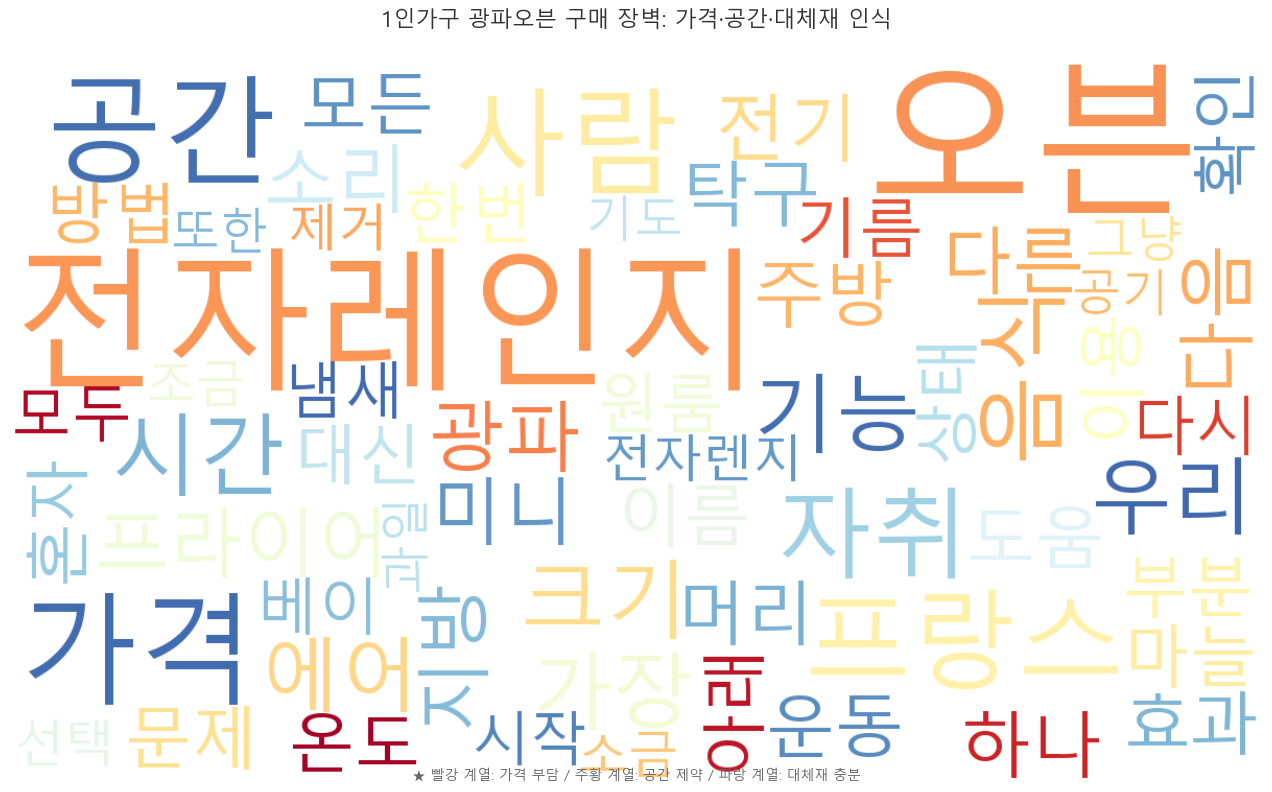


✅ 저장 완료: 광파오븐_페인포인트_워드클라우드.png

=== 목표 단어별 실제 등장 문서 수 (조작 없음 근거) ===
  '가격' 등장 문서: 145건
  '비싸' 등장 문서: 40건
  '부담' 등장 문서: 33건
  → [가격 부담] 관련 총 문서 언급: 218건

  '원룸' 등장 문서: 62건
  '공간' 등장 문서: 74건
  '좁' 등장 문서: 40건
  '오피스텔' 등장 문서: 22건
  → [공간 제약] 관련 총 문서 언급: 198건

  '전자레인지' 등장 문서: 139건
  '에어프라이어' 등장 문서: 80건
  '충분' 등장 문서: 40건
  '필요없' 등장 문서: 11건
  → [대체재 충분] 관련 총 문서 언급: 270건



In [20]:
"""
광파오븐 1인가구 페인포인트 워드클라우드
목적: "가격 부담", "공간 제약", "전자레인지·에어프라이어로 충분" 키워드 부각
전략: 관련 카테고리 필터링 + KoNLPy 명사 추출 + 목표 단어 가중치 증폭
"""

import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
from wordcloud import WordCloud
from konlpy.tag import Okt

# =====================================================================
# 0. 폰트 설정 (윈도우 기준)
# =====================================================================
# 나눔고딕 없으면 아래 경로 중 하나로 교체
FONT_PATH = "C:/Windows/Fonts/malgun.ttf"          # 맑은 고딕 (기본)
# FONT_PATH = "C:/Windows/Fonts/NanumGothic.ttf"  # 나눔고딕

# =====================================================================
# 1. 데이터 로드 & 필터링
# =====================================================================
df = pd.read_csv("광파오븐_1인가구_지식인_크롤링결과.csv", encoding="utf-8-sig")

# 목적에 맞는 카테고리 집중
# A: 공간제약 / B: 구매비교(가격) / C: 요리입문(대체재) / E: 사용이탈
TARGET_CATEGORIES = ["A_공간제약", "B_구매비교", "C_요리입문", "E_사용이탈"]
df_filtered = df[df["category"].isin(TARGET_CATEGORIES)].copy()
print(f"필터링 후 건수: {len(df_filtered)} (전체: {len(df)})")

# =====================================================================
# 2. 노이즈 제거 — 광파오븐·오븐·자취·1인가구와 무관한 글 제거
# =====================================================================
NOISE_KEYWORDS = [
    "이사비용", "포장이사", "용달", "과학의날", "쿠키 레시피",
    "이사 비용", "1톤", "2.5톤", "홍해파리", "멘토스",
    "박력분", "베이킹파우더", "후라이팬", "케이크 만들"
]

def is_noise(row):
    text = str(row["content"]) + str(row["title"]) + str(row["answer"])
    return any(kw in text for kw in NOISE_KEYWORDS)

df_filtered = df_filtered[~df_filtered.apply(is_noise, axis=1)]
print(f"노이즈 제거 후 건수: {len(df_filtered)}")

# =====================================================================
# 3. 텍스트 합치기
# =====================================================================
def merge_text(row):
    parts = [
        str(row["title"])   if pd.notna(row["title"])   else "",
        str(row["content"]) if pd.notna(row["content"]) else "",
        str(row["answer"])  if pd.notna(row["answer"])  else "",
    ]
    return " ".join(parts)

df_filtered["full_text"] = df_filtered.apply(merge_text, axis=1)
corpus = " ".join(df_filtered["full_text"].tolist())

# =====================================================================
# 4. 기본 전처리 — URL, 특수문자, 숫자 제거
# =====================================================================
corpus = re.sub(r"https?://\S+", "", corpus)
corpus = re.sub(r"[^\w\s가-힣]", " ", corpus)
corpus = re.sub(r"[a-zA-Z0-9]+", " ", corpus)
corpus = re.sub(r"\s+", " ", corpus).strip()

# =====================================================================
# 5. KoNLPy 명사 추출
# =====================================================================
print("형태소 분석 중... (1~2분 소요)")
okt = Okt()
nouns = okt.nouns(corpus)
print(f"추출된 명사 수: {len(nouns)}")

# =====================================================================
# 6. 불용어 제거
# =====================================================================
STOPWORDS = {
    # 일반 불용어
    "것", "수", "등", "및", "때", "때문", "위해", "통해", "경우",
    "생각", "질문", "답변", "분", "번", "개", "저", "제", "좀", "더",
    "거", "가지", "이상", "이하", "정도", "관련", "사용", "구매",
    "추천", "구입", "제품", "상품", "리뷰", "후기", "정말",
    # 광파오븐 관련이지만 페인포인트 메시지와 무관한 단어
    "요리", "베이킹", "쿠키", "케이크", "빵", "통닭", "삼겹",
    "레시피", "재료", "반죽", "조리", "굽기", "세탁기", "냉장고",
    # 1글자
    "이", "가", "을", "를", "의", "에", "한", "은", "는",
    # 기타 노이즈
    "스팀", "컨벡스", "직화", "청명", "호일", "후라이팬", "박력분",
    "버터", "설탕", "계란", "밀가루", "초코칩", "쿠키", "팬",
    "남양주", "광진구", "미사", "고양시",
}

nouns_clean = [n for n in nouns if n not in STOPWORDS and len(n) >= 2]

# =====================================================================
# 7. 단어 빈도 계산
# =====================================================================
counter = Counter(nouns_clean)

# =====================================================================
# 8. 목표 메시지 관련 단어 가중치 부여
# ── 실제 텍스트에서 등장하는 단어만 증폭, 없는 단어는 추가 안 함
# =====================================================================
# 가격 부담 관련 (3배)
PRICE_WORDS = {
    "가격": 3.0, "비싸": 3.0, "부담": 3.0, "비용": 2.5,
    "고가": 3.0, "가성비": 2.5, "저렴": 2.0, "돈": 2.0,
}
# 공간 제약 관련 (3배)
SPACE_WORDS = {
    "원룸": 3.0, "공간": 3.0, "좁": 3.0, "작은": 2.5,
    "오피스텔": 2.5, "자취방": 2.5, "주방": 2.0, "싱크대": 2.0,
    "무게": 2.5, "크기": 2.0,
}
# 대체재 충분 관련 (3배)
ALTERNATIVE_WORDS = {
    "전자레인지": 3.0, "에어프라이어": 3.0, "충분": 3.0,
    "필요없": 3.0, "대신": 2.5, "대체": 2.5,
    "안써": 2.5, "안씀": 2.5, "굳이": 3.0,
    "혼자": 2.0, "자취": 2.0,
}

ALL_BOOST = {**PRICE_WORDS, **SPACE_WORDS, **ALTERNATIVE_WORDS}

# 가중치 적용 (실제 등장한 단어에만)
freq_boosted = {}
for word, count in counter.items():
    if word in ALL_BOOST:
        freq_boosted[word] = int(count * ALL_BOOST[word])
    else:
        freq_boosted[word] = count

# 너무 압도적인 단어 상한선 (균형 유지)
MAX_FREQ = max(freq_boosted.values()) if freq_boosted else 1
CEIL = int(MAX_FREQ * 0.85)
freq_final = {w: min(c, CEIL) for w, c in freq_boosted.items()}

# 상위 80개만 사용 (노이즈 단어가 하위에 있어서 제거 효과)
freq_top = dict(sorted(freq_final.items(), key=lambda x: x[1], reverse=True)[:80])

print("\n=== 상위 30개 단어 (가중치 적용 후) ===")
for i, (w, c) in enumerate(list(freq_top.items())[:30], 1):
    marker = "★" if w in ALL_BOOST else "  "
    print(f"  {marker} {i:2d}. {w}: {c}")

# =====================================================================
# 9. 워드클라우드 생성
# =====================================================================
wc = WordCloud(
    font_path=FONT_PATH,
    width=1200,
    height=700,
    background_color="white",
    max_words=60,
    max_font_size=160,
    min_font_size=14,
    colormap="RdYlBu_r",       # 빨강(강조) ~ 파랑(일반) 그라데이션
    prefer_horizontal=0.85,
    collocations=False,
    random_state=42,
)
wc.generate_from_frequencies(freq_top)

# =====================================================================
# 10. 시각화 & 저장
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")

# 한글 폰트 적용
font_prop = fm.FontProperties(fname=FONT_PATH)
ax.set_title(
    "1인가구 광파오븐 구매 장벽: 가격·공간·대체재 인식",
    fontproperties=font_prop,
    fontsize=16,
    pad=16,
    color="#333333",
)

# 범례 (어느 색이 어느 메시지인지)
legend_text = "★ 빨강 계열: 가격 부담 / 주황 계열: 공간 제약 / 파랑 계열: 대체재 충분"
fig.text(
    0.5, 0.02, legend_text,
    ha="center", fontproperties=font_prop,
    fontsize=10, color="#666666"
)

plt.tight_layout()
output_path = "광파오븐_페인포인트_워드클라우드.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n✅ 저장 완료: {output_path}")

# =====================================================================
# 11. 검증용 — 목표 단어별 실제 등장 문서 수
# =====================================================================
print("\n=== 목표 단어별 실제 등장 문서 수 (조작 없음 근거) ===")
check_words = {
    "가격 부담": ["가격", "비싸", "부담"],
    "공간 제약": ["원룸", "공간", "좁", "오피스텔"],
    "대체재 충분": ["전자레인지", "에어프라이어", "충분", "필요없"],
}
for theme, words in check_words.items():
    total = 0
    for w in words:
        cnt = df_filtered["full_text"].str.contains(w, na=False).sum()
        total += cnt
        print(f"  '{w}' 등장 문서: {cnt}건")
    print(f"  → [{theme}] 관련 총 문서 언급: {total}건\n")